## How well do jobs and skills pay for Data Analysts?

### Methodology

- Evaluate median salary for top 6 data jobs
- Find median salary per skill for Data Analysts
- Visualize for highest paying skills and most demanded skills

In [1]:
#Importing libraries
import ast
import seaborn as sns
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

e:\anaconda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
df_IND = df[(df['job_country'] == 'India')].dropna(subset=['salary_year_avg'])

In [7]:
job_titles = df_IND['job_title_short'].value_counts().index[:6].tolist()

job_titles

['Data Engineer',
 'Data Analyst',
 'Data Scientist',
 'Machine Learning Engineer',
 'Senior Data Engineer',
 'Software Engineer']

In [9]:
df_IND_top6 = df_IND[df_IND['job_title_short'].isin(job_titles)]

In [26]:
job_order = df_IND_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

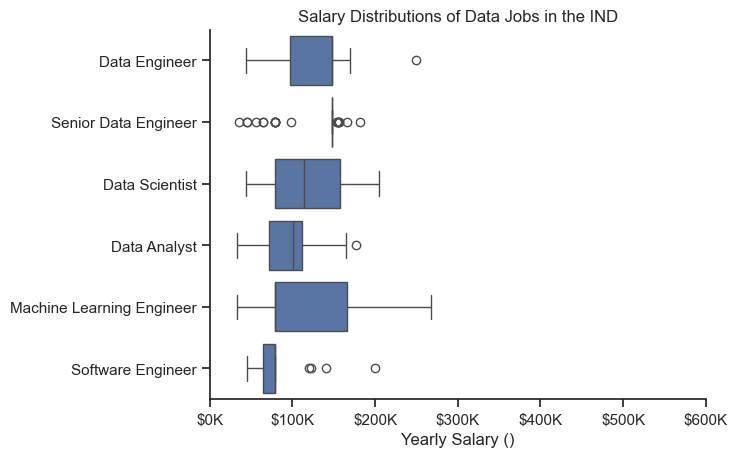

In [28]:
sns.boxplot(data=df_IND_top6, x='salary_year_avg', y='job_title_short',order = job_order)
sns.set_theme(style='ticks')
sns.despine()

# this is all the same
plt.title('Salary Distributions of Data Jobs in the IND')
plt.xlabel('Yearly Salary ()')
plt.ylabel('')
plt.xlim(0, 600000) 
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()